# KNN_Cluster

## From Zero to One

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os

### 数据读取

In [23]:
# 读取数据
m_x = np.loadtxt(
    fname=os.path.join("mnist_x"),
    delimiter=" "
)
m_y = np.loadtxt(
    fname=os.path.join("mnist_y"),
    delimiter=" "  
)

print(
    type(m_x), type(m_y),
    m_x.shape,
    m_y.shape
)

<class 'numpy.ndarray'> <class 'numpy.ndarray'> (1000, 784) (1000,)


(28, 28)


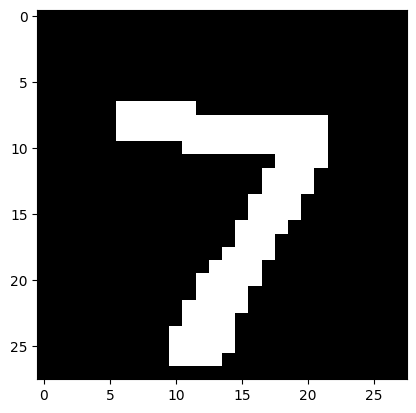

In [24]:
# 可视化数据
## 展示其中一张照片
data = np.reshape(
    m_x[0],
    shape=(28, 28)
)
print(
    # data,
    data.shape,
    sep="\n-----\n"
)
plt.figure()
plt.imshow(
    X=data,
    cmap="gray"
)


### 数据划分

In [25]:
# 划分数据集
ratio = 0.8
split = int(len(m_x[0]) * ratio)
print(
    split,
    len(m_x[0]) - split
)

627 157


In [26]:
# 打乱数据集
np.random.seed(0)
idx = np.random.permutation(len(m_x[0]))
print(idx)
m_x = m_x[idx]
m_y = m_y[idx]
x_train, x_test = m_x[:split], m_x[split:]
y_train, y_test = m_y[:split], m_y[split:]
print(
    x_train.shape, x_test.shape,
    y_train.shape, y_test.shape,
)

[693  85 647 392 765  14 299 711  55  31 122 172 255 502 636 564  75  40
 412 542 710 772 239 252 156  27 500 777 103 365 516 236 751 529 415 401
 588 230 477 493 608 465  79 402 513 366   8 615 215 467 251 193 674 518
 150 609 485 204 436 572 782   1 354 471 113 760 491 774 434 293 315 367
 407 503 272 638 409 640 406 663 363 316 667 196 462 568 596 263 364 692
 716 351 214  18 768 458 735 676 350 242  50 619 752 249 566 162  39 702
 590 283 655  10 620  68 687 222 556 726 766 142   2 776 355 231 770 253
 698 635 618 724 375 382 250 756 338 740 575 202  71  49 631 145 116  37
 548  48 181 492 352 416 390 432  76  64 623  52 720 210 457 499 506 268
 306 285 240 118  12 157 585 175 278 317 331  97 696 261 200 773 576 344
 535 243 686 587  17 301 369 721 356 313 719 327 170 187 706 294  45 333
  62  78 266 312 612 140 198 533 593 127 241 489 399 144 279  21 622 422
  35 496 159 319  77 386 267 601 109 362 310 101 425 540  92 258 235 403
 734 553 781 771 247 211 318 165 505 188 346 487  3

### 算法实现

In [27]:
# 定义距离函数
def distance(a, b):
    return np.sqrt(
        np.sum( (a-b)**2 )
    )

In [28]:
# 定义KNN算法
class KNN:
    def __init__(self, k, label_num):
        self.k = k                      # 近邻数量
        self.label_num = label_num      # 分类标签数量
    
    def fit(self, x_train, y_train):
        # 在对象存储训练数据
        self.x_train = x_train
        self.y_train = y_train
    
    def get_knn_indices(self, x):
        """
        获取与数据点x距离最近的K个近邻样本点
        """
        # 首先计算已知样本到目标样本点的距离
        dis = list(map(lambda a: distance(a,x), self.x_train))
        # 按照距离进行排序
        knn_indices = np.argsort(a=dis)
        # 取得最近的K个下标
        knn_indices = knn_indices[:self.k]
        return knn_indices

    def get_label(self, x):
        """
        观察K个近邻并获取其中类别最多的数量
        """
        knn_indices = self.get_knn_indices(x)
        # 类别计数
        label_statistic = np.zeros( shape=(self.label_num) )
        for index in knn_indices:
            label = int(self.y_train[index])
            label_statistic[label] += 1
        # 返回数量最多的类别
        return np.argmax(label_statistic)

    def predict(self, x_test):
        """
        对测试集数据进行预测
        """
        predicted_test_labels = np.zeros( shape=len(x_test), dtype=int )
        for i, x in enumerate(x_test):
            predicted_test_labels[i] = self.get_label(x)
        return predicted_test_labels

### 数据实验

In [32]:
for k in range(1,10):
    knn = KNN(k=k, label_num=10)
    knn.fit(x_train, y_train)
    predicted_labels = knn.predict(x_test)

    accuracy = np.mean(predicted_labels == y_test)
    print(
        f"近邻K的取值为 {k}, 预测准确率为 {accuracy*100: .1f}%"
    )

近邻K的取值为 1, 预测准确率为  87.9%
近邻K的取值为 2, 预测准确率为  88.5%
近邻K的取值为 3, 预测准确率为  89.8%
近邻K的取值为 4, 预测准确率为  87.9%
近邻K的取值为 5, 预测准确率为  88.5%
近邻K的取值为 6, 预测准确率为  86.6%
近邻K的取值为 7, 预测准确率为  88.5%
近邻K的取值为 8, 预测准确率为  88.5%
近邻K的取值为 9, 预测准确率为  88.5%
